# Dynamic Pricing TS Notebook

This notebook accompanies the  [Thompson Sampling (TS) Dynamic Pricing Tutorial paper](./dyanamic_pricing_ts.md). 

The TS algorithm is modeled numerically with the PyMC Python library for Baysian statistical modeling and probabilistic machine learning. The specific objective of this notebook is to model the posterior probability $P(\theta|Demand),\,  \theta = (a,v, sigma_{log})$. The $\theta$ parameters $(a,v,sigma_{log})$ are parameters coresponding to the constant elasticity of demand, $D(p) = a p ^{-v}$.

After the notebook setup (Imports), the demand and corresponding parameters are chosen, and we visulize the classic demand, price, and profit relationship. Next, we choose the hyperparametes of our statistical model, followed by visualizing the demand likelihood and prior-probabilities of our statistical model. We then setup the PyMc TS Dynamic pricing model, in the form of a Python class. follwed by a TS Dynamic pricing simulation, and then save the results. 

Contents
* Imports and Notebooks Setup
* Demand and TS Parameters
* Economics - Price, Demand, Revenue, Profit
* Demand LogNormal PDF
* Priors - a, v, CV
* Graph - Likelihood and Priors
* PyMC TS Dynamcic Pricing  Model
* TS Dynamic Pricing Simulation
* Save Rusults

The notebook [ts_simulation_results_analysis.ipynb](ts_simulation_results_analysis.ipynb) provides analysis of TS simulation in this notebook.


# Imports

In [1]:
# Good to know the Python version
!python --version

Python 3.12.7


In [2]:
# General Imports
import numpy as np
import pandas as pd
import beautifulplots as bp
import matplotlib.pyplot as plt

import pymc as pm
from math import ceil

import random

# Set Seed
np.random.seed(42) # keeps stats numbers repeatable ... convenientfor initial development

# Demand and TS Parameters

In [3]:
example_case = "case2"

variable_cost = 1.2
fixed_cost = 6
v_true = 1.8
a_true = 4000

# set demand variables
# also set some simulation variables ... this is a convenient place
#   to keep from repeating code logic

# low variability
if example_case == "case1": # hard example 
    CV_true = .05
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6 # w sigma_log .04 can be further away from optimal price

elif example_case == "case2": # medium difficutlty
    CV_true = .20
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6  # w sigma_log .15 need to be closer to target
    Nrounds = 100

elif example_case == "case3" : # hard
    CV_true = .30
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6

else:   # default to None
    v_true = None
    a_true = None
    sigma_log_true = None
    variable_cost = None
    fixed_cost = None
    p1 = None

    
#m_log = a_true + p1 ** (-v_true) # logD before additive noise
#d1m =  a_true * p1 ** (-v_true) * np.exp(sigma_log_true**2 / 2) # E[D] at p1

# p1 = 3.6 corresponds to an initial guess of v = 1.5 with variable cost of 1.2

def print_demand_vars():
    print("DEMAND VARIABLES")
    print(f'  v_true = {v_true}')
    print(f'  a_true = {a_true}')
    print(f'  CV_true = {CV_true}')
    print(f'  sigma_log_true = {round(sigma_log_true,2)}')
    print(f'  variable_cost = {variable_cost}')
    print(f'  fixed_cost = {fixed_cost}')
    print(f"  p1 (initial price point) = {p1}")
    #print(f"  d1m = (E[D] at p1) = {round(d1m,2)}")
    
print_demand_vars()


DEMAND VARIABLES
  v_true = 1.8
  a_true = 4000
  CV_true = 0.2
  sigma_log_true = 0.2
  variable_cost = 1.2
  fixed_cost = 6
  p1 (initial price point) = 3.6


#### Derived Parameters

In [4]:
# derived parameters

if v_true <= 1:
    p_opt  = variable_cost 
else:
    p_opt = (v_true / (v_true - 1)) * variable_cost
    
D_opt = a_true * p_opt **(-v_true)
Profit_opt = p_opt * D_opt - variable_cost * D_opt - fixed_cost  
D_true_p1= a_true * p1 **(-v_true)
Profit_p1 = p1* D_true_p1 - variable_cost * D_true_p1 - fixed_cost
    
print(f'p_opt = {round(p_opt,2)}, ... optimal price given true params')
print(f'D_opt = {round(D_opt,2)}, ... optimal demand given true params')
print(f'Profit_opt = {round(Profit_opt,2)}, ... optimal profit given true params')
print(f'D_true_p1 = {round(D_true_p1,2)}, ... demand true Mean at p1 = {round(p1,2)}')
print(f'Profit_p1 = {Profit_p1}')


p_opt = 2.7, ... optimal price given true params
D_opt = 669.28, ... optimal demand given true params
Profit_opt = 997.91, ... optimal profit given true params
D_true_p1 = 398.76, ... demand true Mean at p1 = 3.6
Profit_p1 = 951.0325999671358


#### Hyperparameters

In [5]:
# Prior a hyperparameters
  #   - important, can get large and blow things out
  #   - careful with  CV = sigma_a / mu_a
  #   - CV = 0.2 tight good (sigma_a = 600/3000), 
  #   - CV = 0.4 = reasonable, well behaved posterior

CV_a = 0.05 # = sigma_linear / mu_linear
m_a_linear  = a_true -100
sigma_a_linear =  CV_a * m_a_linear
sigma_a = np.sqrt(np.log(1 + CV_a**2))
m_a = round(np.log(m_a_linear) - 0.5 * sigma_a**2, 2)

# Prior v hyperparameters 
   #  - ecommerce demand [1.4 , 1.8]
   #  -  sigma_v .3 to .4 good
   #  - sigma_v  0.5 noisy demand ... borderline large
   #  - values near 1 can cause large price swings
   #  - truncated notrmal lower_v hyper ... prevent gettng too close to 1
   # parameters ... m_vtn, signma_v
   
m_v, sigma_v = 1.5, 0.4    #  hyperparameters for prior v
lower_v = 1.1
upper_v = np.inf

if example_case == "case1":
    CV = .06 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case2":
    CV = .18 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case3":
    CV = .4 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
else:
    CV = None
    sigma_log = None

price_min = 2
price_max = 4.0

def print_hyper_params():
    hyper_param_str = f"""
HYPERPARAMETERS
  CV_a = {CV_a}, m_a_linear = {m_a_linear}, sigma_a_linear = {sigma_a_linear}
     m_v = {m_v}, sigma_a = {round(sigma_a,4)}
  m_v {m_v}, sigma_v = {sigma_v}, lower_v = {lower_v}
  CV = {CV}, sigma_log = {round(sigma_log,4)}
  price_min = {price_min}
  price_max = {price_max} """
    
    print(hyper_param_str)


print_hyper_params()


HYPERPARAMETERS
  CV_a = 0.05, m_a_linear = 3900, sigma_a_linear = 195.0
     m_v = 1.5, sigma_a = 0.05
  m_v 1.5, sigma_v = 0.4, lower_v = 1.1
  CV = 0.18, sigma_log = 0.1786
  price_min = 2
  price_max = 4.0 


# TS Model

In [6]:
from dataclasses import dataclass, field
import numpy as np
import pymc as pm
import random
import arviz as az

import contextlib
from pathlib import Path
import logging

from utils_probability import demand_sample


In [7]:
# TS Dynamic Pricing Model Class

@dataclass
class PymcTsModel:
    m_a_linear: float
    sigma_a_linear: float
    m_v: float
    sigma_v: float
    lower_v: float
    CV_d: float
    p0: float
    y0: float
    price_min: float
    price_max: float
    F: float
    c: float
    sigma_log_fixed: float = None
    m_a_linear_fixed: float = None
    log_file: str = "tm_model_log.txt"
    verbose: bool = True

    random_seed: int = 42

    model: pm.Model = field(init=False)
    trace: object = field(init=False, default=None)

    # Optional: keep handles to pm.Data containers
    p_data: pm.Data = field(init=False)
    y_data: pm.Data = field(init=False)
    #y_log_data: pm.Data = field(init=False)

    def __post_init__(self):
        
        # quiet PyMC logging!!!!
        if not self.verbose:
            logging.getLogger("pymc").setLevel(logging.ERROR)
            logging.getLogger("pytensor").setLevel(logging.ERROR)
        
        
        # histories live outside the PyMC model context
        self.traces = []
        self.price_history = []
        self.demand_history = []

        # build model + take initial posterior
        self.init_ts_pricing_model()

        # store initial trace + initial observation
        self.traces.append(self.trace)
        self.price_history.append(self.p0)
        self.demand_history.append(self.y0)
        
        
    @contextlib.contextmanager
    def _redirect_io(self):
        if self.verbose:
            yield
            return

        Path(self.log_file).parent.mkdir(parents=True, exist_ok=True)
        with open(self.log_file, "a", buffering=1) as f, \
            contextlib.redirect_stdout(f),  contextlib.redirect_stderr(f):
            yield
            

    def init_ts_pricing_model(
        self,
        draws: int = 1000,
        tune: int = 2000,
        chains: int = 2,
        target_accept: float = 0.99,
    ):
        with pm.Model() as model:
            # ---- Prior for a (LogNormal) ----
            cv2_a = (self.sigma_a_linear / self.m_a_linear) ** 2
            sigma_loga = np.sqrt(np.log1p(cv2_a))
            mu_loga = np.log(self.m_a_linear) - 0.5 * sigma_loga**2

            # ---- Prior for v (truncated normal) ----
            v = pm.TruncatedNormal(
                "v",
                mu=self.m_v,
                sigma=self.sigma_v,
                lower=self.lower_v,
            )

            # ---- a (learned or fixed) ----
            if self.m_a_linear_fixed is None:
                a = pm.LogNormal("a", mu=mu_loga, sigma=sigma_loga)
            else:
                a = pm.Deterministic(
                    "a",
                    0 * v + self.m_a_linear_fixed,
                )   
            loga = pm.Deterministic("loga", pm.math.log(a))

            # ---- Prior for sigma_log (log-space noise, learned or fixed) ----
            if self.sigma_log_fixed is None:
                sigma_log_scale = np.sqrt(np.log1p(self.CV_d**2))
                sigma_log = pm.HalfNormal(
                    "sigma_log",
                    sigma=sigma_log_scale,
                )
            else:
                sigma_log = pm.Deterministic(
                    "sigma_log",
                    0 * v + self.sigma_log_fixed,
                )
            # cv useful when sigma_log not constant
            cv = pm.Deterministic( "cv",   pm.math.sqrt(pm.math.exp(sigma_log**2) - 1))

            # ---- Mutable data containers ----
            self.p_data = pm.Data("p_data", np.array([self.p0], dtype=np.float64))
            self.y_data = pm.Data("y_data", np.array([self.y0], dtype=np.float64))

            # ---- Log-space likelihood (multiplicative noise) ----
            mu_log = loga - v * pm.math.log(self.p_data)
            pm.LogNormal("D_obs", mu=mu_log, sigma=sigma_log, observed=self.y_data)

            self.model = model

            with self._redirect_io():
                self.trace = pm.sample(
                    draws=draws,
                    tune=tune,
                    chains=chains,
                    target_accept=target_accept,
                    random_seed=self.random_seed,
                    progressbar=self.verbose,
                )

        return self.trace

    # bump 
    def price_anchor_deviation(self, percent_change=0.1, anchor_p_opt_flag = True, max_local_price_change_tf = False):
        """
        Apply a +/- price change alternating up or down from a base price (p_opt or latest price history point).

        Args:
            percent_change (float): maximum percent change (default 0.10)
            
            anchor_p_opt_flag (bool): if True, use global optimal price estimate as base; if False, use latest price history point as base
            
            max_change_tf (bool): if True, apply the full max_percent_change; if False, apply a random percent change uniformly drawn from [0, max_percent_change]

        Returns:
            float: new price constrained to global bounds and rounded to 2 decimals
        """
        
        if anchor_p_opt_flag:
            # global optimal price estimate
            _p = self.price_global_popt_expected_profit()
        else:
            # adjust to max amount from latest offer
            _p = self.price_history[-1] # adjust on price_history as tighten is better ,
        
        # initialize direction if first call
        if not hasattr(self, "_last_direction"):
            self._last_direction = np.random.choice([-1, 1])
        else:
            self._last_direction *= -1  # alternate direction
            
        if max_local_price_change_tf:
            # max change
            _percent_change = percent_change
        else: 
            # random
            _percent_change = np.random.uniform(0, percent_change)
            
        #print(f'\n...  _p = {_p}, percent_change = {round(percent_change,4)}, direction = {self._last_direction}')
            
        new_price = _p * (1 + self._last_direction * _percent_change)

        # enforce global bounds
        new_price = float(np.clip(new_price, self.price_min, self.price_max))

        return round(new_price, 2)
            
            
    def _flatten_posterior_draws(self, var_name: str) -> np.ndarray:
        """
        Return posterior draws for `var_name` as a 1D numpy array.
        Assumes init_ts_pricing_model() has already been run.
        """
        return self.trace.posterior[var_name].values.reshape(-1)
    
    # Offer Price             
    def price_max_profit_sample(self, max_price_change = None , Npgrid=40, K=1, limit_price_change = True):
        """
        Price that maximizes local profit given a price change constraint and K parameter sample (defaults to K = 1).
        - parameters a and v are drawn from the posterior trace (K samples)
        - optimization is inside the allowed price change region ("trust region") only 
        - price that maximizes the profit given the sample parameters a, v (i.e., v is a new demand curve)

        Args:
            max_price_change (float)): should be a percent (<= 1)
            Npgrid (int, optional): Number of price grid points. Defaults to 40


        Returns:
            float: price that otimizes the profit given parameter sample(s)
        """
        
        # Note 

        price_min = self.price_history[-1] * (1 - max_price_change)
        price_max = self.price_history[-1] * (1 + max_price_change)
        
        # Optimize profit ONLY inside allowed price change region
        
        if limit_price_change:
            price_min = max(price_min, self.price_min)
            price_max = min(price_max, self.price_max)
        else:
            price_min = self.price_min
            price_max = self.price_max

        p_grid = np.linspace(price_min, price_max, Npgrid)
        idx = np.random.randint(self.trace.posterior["a"].values.size, size = K)
        a_s = self.trace.posterior["a"].values.reshape(-1)[idx] # sample
        v_s = self.trace.posterior["v"].values.reshape(-1)[idx] # sample
        
        if K == 1:
            a1 = float(a_s[0])
            v1 = float(v_s[0])
            profit_local = np.array([(p - self.c) * a1 * (p ** (-v1)) - self.F for p in p_grid])
        else:
            profit_local = np.array([np.mean((p-self.c)*a_s*p**(-v_s)) - self.F for p in p_grid])

        price = p_grid[int(np.argmax(profit_local))]
        
        price = max(price, self.price_min) # stay within global bounds
        price = min(price, self.price_max) # stay within global bounds
        
        return round(price,2)

    def price_global_popt_expected_profit(self, Npgrid=200) -> float:
        """
        Bayes action: p that maximizes posterior expected profit.
        Uses posterior draws of (a, v). (sigma_log cancels in expectation if you use median demand;
        """
        a_s = self._flatten_posterior_draws("a")
        v_s = self._flatten_posterior_draws("v")

        p_grid = np.linspace(self.price_min, self.price_max, Npgrid)

        # expected profit under posterior
        exp_profit = np.array([
            np.mean((p - self.c) * a_s * (p ** (-v_s)) - self.F)
            for p in p_grid
        ])

        return float(p_grid[int(np.argmax(exp_profit))])
    
    def sampler_health(self, idata, rhat_thresh=1.01, ess_thresh=100, print_warning=True):
        """
        Extracts the algorithm convergence health statistics

        Args:
            idata (np.array): the trace, inference data
            rhat_thresh (float, optional): Threshold for comparing model's . Defaults to 1.01.
            ess_thresh (float, optional): Threshold for minimum effective sample size. Defaults to 100.
            print_warning (bool, optional): If True, prints a compact warning message when thresholds are violated.

        Returns:
            dict: Dictionary of convergence diagnostics including divergences, rhat, and ESS metrics.
            
        Note about Rhat threshold:
        Rhat = 1 only in the infinite-sample limit with perfectly mixed chains.
        With finite draws, Monte Carlo noise almost always gives 
        Rhat >1.
        Empirical and theoretical work (Vehtari et al., 2021) shows that
        *      ≤ 1.01 → acceptable for most applied work
        *     Rhat 1.01–1.05 → warning
        *     > 1.05 → unreliable
        That’s why PyMC/ArviZ and the literature flag 1.01, not 1.00, as the practical cutoff.

        Note about ESS:
        Effective Sample Size (ESS) measures the number of independent samples after accounting
        for autocorrelation in the MCMC chains. Low ESS indicates poor mixing or strong posterior
        correlation. Bulk ESS reflects central tendency; tail ESS reflects tail exploration.
        """

        divergences = int(idata.sample_stats["diverging"].values.sum())

        # Only evaluate rhat on sampled parameters
        #var_names = ["a", "v", "sigma_log"]
        
        sigma_fixed = self.sigma_log_fixed is not None # True if sigma_log_fixed is not None
        a_fixed = self.m_a_linear_fixed is not None # true if m_a_linear fixed is not None

        if sigma_fixed and a_fixed:
            var_names = ["v"]
        elif sigma_fixed and not a_fixed:
            var_names = ["a", "v"]
        elif not sigma_fixed and a_fixed:
            var_names = ["sigma_log", "v"]
        else:
            var_names = ["a", "v", "sigma_log"]
        
        rhat = az.rhat(idata, var_names=var_names).to_array()
        ess_bulk = az.ess(idata, var_names=var_names, method="bulk").to_array()
        ess_tail = az.ess(idata, var_names=var_names, method="tail").to_array()

        result = {
            "divergences": divergences,
            "max_rhat": float(rhat.max()),
            "n_rhat_gt": int((rhat > rhat_thresh).sum()),
            "min_ess_bulk": float(ess_bulk.min()),
            "min_ess_tail": float(ess_tail.min()),
            "n_ess_bulk_lt": int((ess_bulk < ess_thresh).sum()),
            "n_ess_tail_lt": int((ess_tail < ess_thresh).sum()),
        }

        # ---- Compact warning print ----
        if print_warning:
            if (
                result["divergences"] > 0
                or result["max_rhat"] > rhat_thresh
                or result["min_ess_bulk"] < ess_thresh
                or result["min_ess_tail"] < ess_thresh
            ):
                print(
                    f", WARNING div={result['divergences']}, "
                    f"rhat={result['max_rhat']:.3f}, "
                    f"ess_bulk={result['min_ess_bulk']:.1f}, "
                    f"ess_tail={result['min_ess_tail']:.1f}",
                    end=""
                )

        return result
        

    def model_update(self, price, demand, draws=1000, tune=2000, **kwargs ):
        
        self.price_history.append(price)
        self.demand_history.append(demand)
        
        # quiet this function down!!!!
        # capture the verbose model output and redirect to log_file .. 

        #update data
        with self.model:
            # Posterior Update  
            pm.set_data({
            "p_data": np.asarray(self.price_history, dtype=np.float64),
            "y_data": np.asarray(self.demand_history, dtype=np.float64),
            })
            
        # update model
        with self._redirect_io():       
            with self.model:
                self.trace = pm.sample(
                    draws=draws,
                    tune=tune,
                    target_accept=0.99,
                    chains=2,
                    init="adapt_diag",
                    random_seed=self.random_seed + len(self.price_history),
                    progressbar=self.verbose,  
                    **kwargs,
                )
                    
        return self.trace

# TS Iteration

In [8]:
# LOOP PARAMETERS
_simulate = True # default false ... this will take long

##### --- SIM PARAMETERS ---- ##### 
# price control ... if false, no limit on price channge tm.price_max_profit_sample() method
limit_price_change = True

# random local or max local
max_local_price_change_tf = True

fix_sigma_log = True # keep noise variance fixed.
if fix_sigma_log:
    fixed_sigma_log = sigma_log
else:
    fixed_sigma_log_fixed = None


a_fixed = False
if a_fixed==True:
    #m_a_linear_fixed = a_true # convergence test with a_true
    m_a_linear_fixed = m_a_linear

else:
    m_a_linear_fixed = None

##### ------ New Offered Price from Samples ------- ######
# - how often to sample for a new offered price
# - othwerwise explore areound the previous sampled price
repeat_deviation_1 = 0
repeat_deviation_2 = 0

##### ----- initial prices -----########

# note CV_mean = CV / sqrt(n) ... n = (CV / CV_target)**2
#CV_target = .1 # moderately stable early learning
initial_prices =[p1]

##### -------- Case Specific  Variables ------ ######
        
# example cases and variables
if example_case == "case1": # hard example 
    Nrounds = 50
    N_price_repeat = 2 # effective repeat sample price n-1
    initial_prices = [p1]
    max_price_change_1 = 1 # 10%
    max_price_change_2 = 0.025 # 10%
    K1 = 1
    K2 = 3
    Nk = 75
elif example_case == "case2": # medium difficutlty
    N_price_repeat = 3 # effective repeat sample price n-1
    Nrounds = 30
    initial_prices = [p1]
    initial_prices = [3.6, 2.3]
    max_price_change_1 = 1 # 100%
    max_price_change_2 = 0.05 # 5%
    K1 = 2
    K2 = 1
    Nk = 15
    price_anchor_1 = False
    price_anchor_2 = True
elif example_case == "case3" : # hard
    N_price_repeat = 5 #repeat price
    Nrounds = 150
    initial_prices = [3.3, 3.0, 2.7, 2.4, 2.1]
    K1 = 3
    K2 = 3
    Nk = 25

else:   # default to None
    Nrounds = 10
    K1 = 1
    K2 = 2
    Nk = 10
    Nth_max_local = 3 # Nth time pick random price ... N large effectively turns off
    
#local_price_percent = 0.25
verbose = False

In [9]:
# PRINT PARAMETERS
print(f'example_case = {example_case}')
print()
print_demand_vars() # Demand Variables
print()
print_hyper_params() # Hyper Parameters

variable_defs = """
SIM VARIABLES
"""

print()
print(variable_defs)
#initial_prices = [_p for _p in initial_prices for _ in range(n_initial_prices)]    

print(f'initial_prices = {initial_prices}')
### Initialize Variables

print(f'  fix_sigma_log = {fix_sigma_log}')
if fix_sigma_log:
    print(f'    sigma_log_fixed = {round(fixed_sigma_log,4)}')
    
print(f'  a_fixed = {a_fixed}')
if a_fixed:
    print(f'    m_a_linear_fixed = {m_a_linear_fixed}')
    
print(f'  Nrounds = {Nrounds}, the total number of iteration steps')
print(f'  Nk = {Nk}, Nk : i < Nk _1 variables, i >= Nk   _2 variables')
print(f'  K1 = {K1}, K1 samples for i < Nk')
print(f'  K2 = {K2}, K2 samples for i >= Nk')
print(f'  N_price_repeat = {N_price_repeat}, repeate the offered price N times')
print(f'  initial_prices = {initial_prices}')
print(f'  max_local_price_change_1 = {max_price_change_1}')
if max_local_price_change_tf:
    print(f'  price_anchor_1 = {price_anchor_1}')
    print(f'  price_anchor_2 = {price_anchor_2}')
print(f'  limit_price_change = {limit_price_change}, True/False. If True then limit i step to step price change')
if limit_price_change:
    print(f'    max_price_change_1 = {max_price_change_1},  max_price_change_1 for i < Nk')
    print(f'    max_price_change_2 = {max_price_change_2} max_price_change_2 for i >= Nk')
print(f'    price_anchor_1 = {price_anchor_1}')
print(f'    price_anchor_2 = {price_anchor_2}')
print(f'    repeat_deviation_2 = {repeat_deviation_1}')
print(f'    repeat_deviation_2 = {repeat_deviation_2}')




example_case = case2

DEMAND VARIABLES
  v_true = 1.8
  a_true = 4000
  CV_true = 0.2
  sigma_log_true = 0.2
  variable_cost = 1.2
  fixed_cost = 6
  p1 (initial price point) = 3.6


HYPERPARAMETERS
  CV_a = 0.05, m_a_linear = 3900, sigma_a_linear = 195.0
     m_v = 1.5, sigma_a = 0.05
  m_v 1.5, sigma_v = 0.4, lower_v = 1.1
  CV = 0.18, sigma_log = 0.1786
  price_min = 2
  price_max = 4.0 


SIM VARIABLES

initial_prices = [3.6, 2.3]
  fix_sigma_log = True
    sigma_log_fixed = 0.1786
  a_fixed = False
  Nrounds = 30, the total number of iteration steps
  Nk = 15, Nk : i < Nk _1 variables, i >= Nk   _2 variables
  K1 = 2, K1 samples for i < Nk
  K2 = 1, K2 samples for i >= Nk
  N_price_repeat = 3, repeate the offered price N times
  initial_prices = [3.6, 2.3]
  max_local_price_change_1 = 1
  price_anchor_1 = False
  price_anchor_2 = True
  limit_price_change = True, True/False. If True then limit i step to step price change
    max_price_change_1 = 1,  max_price_change_1 for i < Nk
 

In [10]:
# ITERATION LOOP

#### --- histories ---- ####
prices_history = []
demands_history = []
p_optest_history = [] # estimated optimal price history
v_est_history = [] # posterior means history for v 
a_history = []
v_history = []
cv_history = []
sigma_log_history = []
traces = []

#### ----- SIMULATION LOOP ---- #####
local_updown = +1
pos_neg = +1
last_probe_direction = 1
t2 = 1
price_count = 0
new_price=False
if _simulate == True: 
    for t in range(1,Nrounds+1):  # first round only
        #print()
        print(5*"*",f' t = {t}', end = "")
        
        if t == 1:
            # 1 offer price
            offer_price = initial_prices[t2-1]
            print(f', new offer_price = initial_price[{t-1}] = {offer_price}', end = ", ")
            price_count += 1
            
            # 2 demand

            demand_p1 = float(np.squeeze(demand_sample(offer_price, a_true, v_true, sigma_log_true)))
            demand_p1 = max(demand_p1, 1e-6)
            
            # 3. Price and Demand History
            prices_history.append(offer_price)
            demands_history.append(demand_p1)
            print(f', observed demand = {np.round(demand_p1,2)}\n...', end="")
            
            # 4. posterior model
            tm = PymcTsModel(
                m_a_linear=m_a_linear, sigma_a_linear=sigma_a_linear,
                m_v=m_v, sigma_v=sigma_v, lower_v=lower_v,
                CV_d=CV, # CV prior
                p0=p1, 
                y0=demand_p1,
                price_min = price_min, price_max = price_max, # global max, min limits
                F = fixed_cost,
                c = variable_cost,
                verbose = verbose,
                sigma_log_fixed = fixed_sigma_log,
                m_a_linear_fixed = m_a_linear_fixed
            )
            
            tm_trace_health_status = tm.sampler_health(tm.trace)
            
        else:
            # 1) Offer Price
            # -- anchor price ... for price repetition with +/deviation 
            if price_count == N_price_repeat:
                new_price = True
                price_count = 1
            else:
                new_price = False
                price_count += 1
                
            # -- price_anchor
            price_anchor = price_anchor_1 if t < Nk  else price_anchor_2
                
            # - limit on price change when calculating a new price from the sample
            repeat_deviation = repeat_deviation_1 if t < Nk else repeat_deviation_2
            max_price_change = max_price_change_1 if t < Nk else max_price_change_2
            prev_offer_price = offer_price
            
            if t2 <= len(initial_prices)-1:
                # initial prices
                if new_price:
                    offer_price = initial_prices[t2]
                    print(f', new offer_price = initial_price[{t2}] = {offer_price}', end = ", ")
                else:
                    # repeat offer price
                    local_updown *= -1   # alternate
                    offer_price = prev_offer_price * (1 + local_updown * repeat_deviation)
                    offer_price = float(np.clip(offer_price, price_min, price_max))
                    offer_price = round(offer_price, 2)
                    print(f', offer price (+/- local_deviation = {repeat_deviation}) = {offer_price}', end = "")
                
            # > len(initial_prices) ... sample new price every Nth time, otherwise explore around previous price
            elif new_price:
                if price_anchor:
                    # new local price
                    offer_price = tm.price_anchor_deviation(max_price_change,max_local_price_change_tf = max_local_price_change_tf)
                    print(f', new offer price, anchor +/- deviation = {offer_price}', end = "")
                else:
                    # sampling price
                    K = K1 if t < Nk else K2
                    # note the limit price change
                    offer_price = tm.price_max_profit_sample(max_price_change, K=K, limit_price_change=limit_price_change)
                    print(f', new offer price sample, (K = {K}) = {offer_price}', end = "")
            
            else:
                # local variation
                local_updown *= -1   # alternate
                offer_price = prev_offer_price * (1 + local_updown * repeat_deviation)
                offer_price = float(np.clip(offer_price, price_min, price_max))
                offer_price = round(offer_price, 2)
                print(f', offer price (+/- local_deviation = {repeat_deviation}) = {offer_price}', end = "")
        
            # 2) Observe demand (simulated here)
            #demand_s =  demand_sample(offer_price,a_true, v_true, sigma_log_true)  # 
            #demand_s = max(demand_s, 1e-6) # ensure greater than zero
            
            demand_s = float(np.squeeze(demand_sample(offer_price, a_true, v_true, sigma_log_true)))
            demand_s = max(demand_s, 1e-6)

            # 3) Store history
            prices_history.append(offer_price)
            demands_history.append(demand_s)
            print(f', observed demand = {round(demand_s,2)}\n...', end="")

            # 4) Update posterior
            tm.model_update(offer_price, demand_s)
            
            tm_trace_health_status = tm.sampler_health(tm.trace)
            
        # 5. store trace
        traces.append(tm.trace)

        # 6. Parameter Estimates
        a_mean  = tm.trace.posterior["a"].mean().item()
        v_mean  = tm.trace.posterior["v"].mean().item()
        sigma_log_mean = tm.trace.posterior["sigma_log"].mean().item()
        #cv_sd   = tm.trace.posterior["cv"].std().item()
        
        a_sd  = tm.trace.posterior["a"].std().item()
        v_sd  = tm.trace.posterior["v"].std().item()
        sigma_log_sd = tm.trace.posterior["sigma_log"].std().item()
        cv_mean = tm.trace.posterior["cv"].mean().item()

        # 7. Price Optimum Estimate ... p_opt_est
    
        #p_opt_est = tm.price_global_max_profit()
        
        p_opt_est = tm.price_global_popt_expected_profit()
        
        print(f' sigma_log_mean = {round(sigma_log_mean,4)}, a_mean = {round(a_mean)}. v_mean = {round(v_mean,3)}, p_opt_est = {round(p_opt_est,4)}')
        
        # 8. Update Histories
        p_optest_history.append(p_opt_est)
        a_history.append(a_mean)
        v_history.append(v_mean)
        cv_history.append(cv_mean)
        sigma_log_history.append(sigma_log_mean)
        
        # increment t2 ... for initital prices
        if new_price: 
            t2+=1
        
else:
    print()
    print(f"_simulate = {False}. Set _simulate = True to run a new simulation.")
    
        

*****  t = 1, new offer_price = initial_price[0] = 3.6, , observed demand = 439.98
... sigma_log_mean = 0.1786, a_mean = 3880. v_mean = 1.679, p_opt_est = 3.0251
*****  t = 2, offer price (+/- local_deviation = 0) = 3.6, observed demand = 387.99
... sigma_log_mean = 0.1786, a_mean = 3874. v_mean = 1.732, p_opt_est = 2.8643
*****  t = 3, offer price (+/- local_deviation = 0) = 3.6, observed demand = 453.34
... sigma_log_mean = 0.1786, a_mean = 3883. v_mean = 1.715, p_opt_est = 2.8945
*****  t = 4, new offer_price = initial_price[1] = 2.3, , observed demand = 1207.66
... sigma_log_mean = 0.1786, a_mean = 3907. v_mean = 1.683, p_opt_est = 2.9749
*****  t = 5, offer price (+/- local_deviation = 0) = 2.3, observed demand = 852.73
... sigma_log_mean = 0.1786, a_mean = 3912. v_mean = 1.699, p_opt_est = 2.9246
*****  t = 6, offer price (+/- local_deviation = 0) = 2.3, observed demand = 852.73
... sigma_log_mean = 0.1786, a_mean = 3879. v_mean = 1.698, p_opt_est = 2.9347
*****  t = 7, new offer

df_ts_summary dataframe 

In [11]:

F = fixed_cost # fixed cost
c = variable_cost # variable cost
ph = np.array(prices_history) # price history

P = (ph -c)* (a_true * ph **(-v_true)) - F

_df_ts_summary = pd.DataFrame({
    "n": range(1, Nrounds+1),
    "price_history": prices_history,
    "demand_history": demands_history, 
    "price_optest_history": p_optest_history,
    "a_history": a_history,
    "v_history": v_history,
    "cv_history": cv_history,
    "sigma_log_history": sigma_log_history,
    "profit_history": P
})

print(f'_df_summary_ts.shape = {_df_ts_summary.shape}')

_df_summary_ts.shape = (30, 9)


# Price Convergence Plot

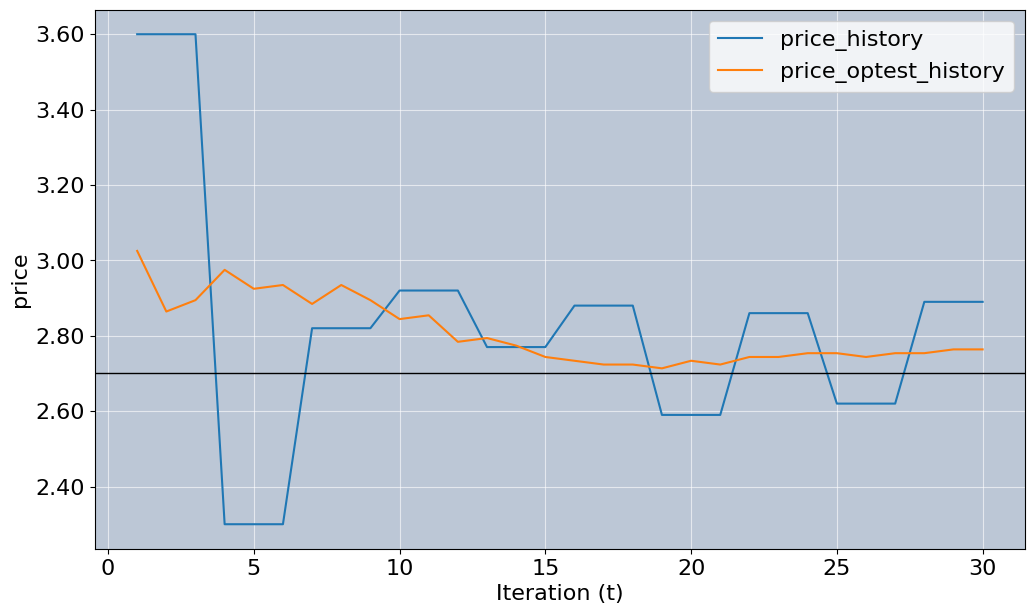

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
bp.lineplot(
    _df_ts_summary, x ="n",
    y = ["price_history", "price_optest_history"], 
    y_axis_label='price',
    x_axis_label='Iteration (t)',
    h_line = p_opt,
    #y_lims = (2, 4.5),
    #x_lims = (1, 10),
    figsize=(12,6),
    ax = ax
    )

background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
ax.set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
ax.grid(True, color=grid_color, alpha=grid_alpha)

plt.show()

# Save

In [13]:
#from datetime import date
from datetime import datetime
import json
import os
import arviz as az
from pathlib import Path


now = datetime.now()
date_iso_str = now.strftime("%Y%m%d%H%M")  # e.g. 202602220731
_save_sim_results = True # on by default

if _save_sim_results == True:
    print(f'example_case = {example_case}')
    now = datetime.now()
    date_iso_str = now.strftime("%Y%m%d%H%M")  # e.g. 202602220731
    file_name = f"ts_sim_results_{example_case}_{date_iso_str}.json"
    save_dir = "./data_sim_results"
    file_path = f'{save_dir}/{file_name}'
    traces_dir = Path(save_dir) / f"ts_traces_{example_case}_{date_iso_str}"
    traces_dir.mkdir(parents=True, exist_ok=True)
    
    print(f'file_path = {file_name}')
    print(f'traces_dir = {traces_dir}')

    # data to save
    data_sim_dict = {
        "example_case": example_case,
        "p1": p1,
        "a_true": a_true,
        "v_true": v_true,
        "CV_true": CV_true,
        "initial_prices": initial_prices,
        "K1": K1,
        "K2": K2,
        "Nk": Nk,
        "fix_sigma_log": fix_sigma_log,
        "a_fixed": a_fixed, 
        "m_a_linear_fixed": m_a_linear_fixed,
        "limit_max_price_change": limit_price_change,
        "max_price_change_1": max_price_change_1,
        "max_price_change_2": max_price_change_2,
        "sigma_log_true": sigma_log_true,
        "fixed_cost": fixed_cost,
        "variable_cost": variable_cost,
        "Nrounds": Nrounds,
        "initial_prices": initial_prices,
        "N_price_repeat" : N_price_repeat,
        "max_local_price_change_tf": max_local_price_change_tf,
        "price_anchor_1": price_anchor_1,
        "price_anchor_2": price_anchor_2,
        "local_deviation_1": repeat_deviation_1,
        "local_deviation_2": repeat_deviation_2,
        "hyperparameters": {
            "m_a": m_a,
            "sigma_a": sigma_a,
            "m_v": m_v,
            "sigma_v": sigma_v,
            "lower_v": lower_v,
            "sigma_log": sigma_log,
            "max_price_change": max_price_change,
            "min_price": price_min,
            "max_price": price_max
        },
        "df_ts_summary_str":_df_ts_summary.to_json(orient='records', date_format='iso'),
        "traces_dir": str(traces_dir),
        "n_traces": len(traces),
        "traces_format": "netcdf"
        }
    
    
    # Save parameters and dataframe
    #    - Open a file in write mode ('w') and save the dictionary as JSON
    with open(file_path, "w") as json_file:
        json.dump(data_sim_dict, json_file, indent=4)
        
    # Save traces seperately
        
    for t, idata in enumerate(traces, start=1):
        az.to_netcdf(idata, traces_dir / f"trace_t{t:03d}.nc")

else:
    print(f"_save_sim_results = {_save_sim_results}. Set _save_sim_results = True to save simulation results.")

example_case = case2
file_path = ts_sim_results_case2_202604201432.json
traces_dir = data_sim_results/ts_traces_case2_202604201432


What is Arviz?  
* Python library is an open-source package for the exploratory analysis of Bayesian models. It provides a unified, backend-agnostic interface for visualizing, diagnosing, and comparing the results of Bayesian inference, working with output from various probabilistic programming libraries (PPLs). 


NetCDF?
* Preserves posterior samples, coords, attrs
* Fast, compact, lossless
* Standard across PyMC / Stan / ArviZ
* Reloads instantly into InferenceData